# ELMFIRE Simulation Output Visualizer

Visualizes the four output types from an ELMFIRE Tutorial 03 fire simulation:
- `hourly_isochrones.shp` — hourly fire perimeters (shapefile)
- `time_of_arrival_*.tif` — raster of when fire reached each cell
- `flin_*.tif` — fireline intensity raster (kW/m)
- `fire_size_stats.csv` — fire area over time

**Run all cells top-to-bottom.** Outputs land in `docker_shared_folder/simulation/outputs/`.

## 1. Install & Import Libraries

In [12]:
# Install required packages (run once)
%pip install geopandas rasterio matplotlib pandas numpy contextily folium mapclassify --quiet

Note: you may need to restart the kernel to use updated packages.


In [13]:
import glob
import os
from pathlib import Path

import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.colors import BoundaryNorm, Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import pandas as pd
import rasterio
from rasterio.plot import show as rioshow
import warnings
warnings.filterwarnings("ignore")

# ── Output directory (relative to this notebook) ──────────────────────────────
OUTPUTS = Path("docker_shared_folder/simulation/outputs")
assert OUTPUTS.exists(), f"Outputs not found at {OUTPUTS.resolve()}. Run the simulation first."
print(f"Output directory: {OUTPUTS.resolve()}")
print(f"Files found: {[p.name for p in OUTPUTS.iterdir()]}")

Output directory: C:\Users\ashsh\OneDrive\Documents\GitHub\elmfire\elmfire-src\docker_shared_folder\simulation\outputs
Files found: ['fire_size_stats.csv', 'flin_0000001_0021605.bil', 'flin_0000001_0021605.hdr', 'flin_0000001_0021605.tif', 'flin_0000001_0021605_viz.png', 'hourly_isochrones.dbf', 'hourly_isochrones.prj', 'hourly_isochrones.shp', 'hourly_isochrones.shx', 'time_of_arrival_0000001_0021605.bil', 'time_of_arrival_0000001_0021605.hdr', 'time_of_arrival_0000001_0021605.tif', 'time_of_arrival_0000001_0021605_viz.png', 'viz_combined_summary.png', 'viz_fire_size_stats.png', 'viz_interactive_map.html', 'viz_isochrones.png', 'vs_0000001_0021605.bil', 'vs_0000001_0021605.hdr', 'vs_0000001_0021605.tif']


## 2. Hourly Fire Perimeters (Shapefile)
Each contour line = the fire boundary at that hour. Color = time of burn.

In [14]:
shp_path = OUTPUTS / "hourly_isochrones.shp"
iso = gpd.read_file(shp_path)

print(f"CRS: {iso.crs}")
print(f"Columns: {iso.columns.tolist()}")
print(iso.head())

# Reproject to Web Mercator for basemap alignment
iso_wm = iso.to_crs(epsg=3857)

# Determine which column best encodes time / contour level
color_col = None
for c in iso.columns:
    if c.lower() in ("elev", "level", "time", "hour"):
        color_col = c
        break
if color_col is None:
    # Fall back to ID — gdal_contour assigns sequential IDs from inner to outer
    color_col = "ID" if "ID" in iso.columns else [c for c in iso.columns if c != "geometry"][0]

print(f"\nUsing '{color_col}' column for color coding")

CRS: EPSG:32610
Columns: ['ID', 'geometry']
   ID                                           geometry
0   0  LINESTRING (737071.56 4265778.379, 737056.56 4...
1   1  LINESTRING (737281.56 4265644.448, 737266.713 ...
2   2  LINESTRING (737341.56 4265621.948, 737326.56 4...
3   3  LINESTRING (736608.884 4265355, 736606.56 4265...
4   4  LINESTRING (737671.56 4265323.223, 737656.56 4...

Using 'ID' column for color coding


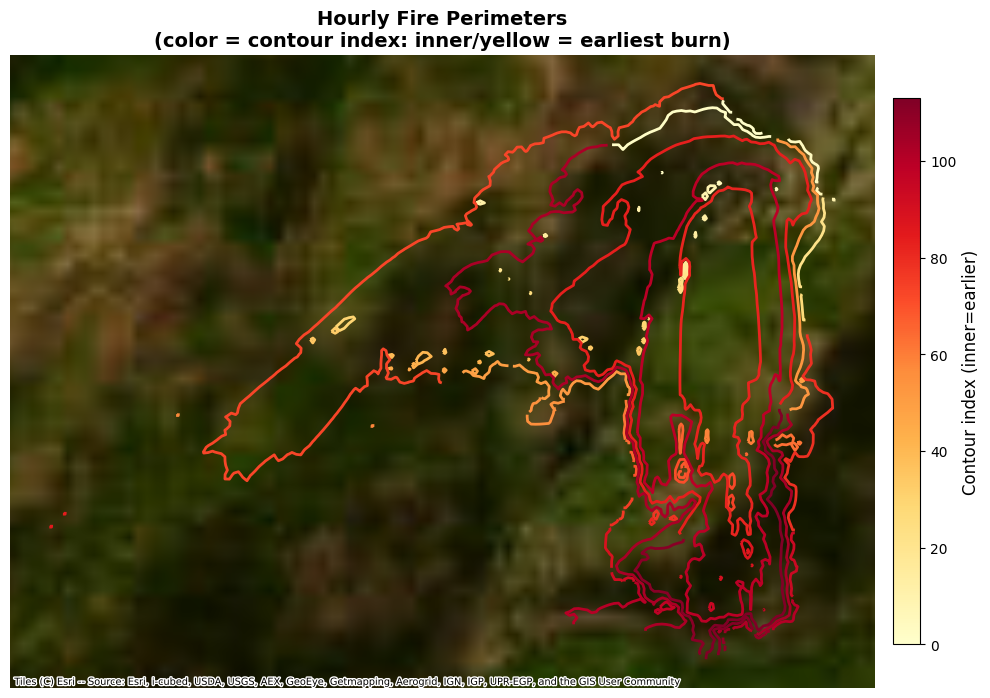

Saved: viz_isochrones.png


In [15]:
fig, ax = plt.subplots(figsize=(10, 10))

# gdal_contour assigns sequential IDs; lower ID = inner/earlier perimeter
# (contours are traced from lowest to highest time value, so ID is a proxy for time)
vals   = iso_wm[color_col]
label  = "Contour index (inner=earlier)" if color_col == "ID" else color_col

cmap = plt.cm.YlOrRd
norm = Normalize(vmin=vals.min(), vmax=vals.max())

iso_wm.plot(
    column=color_col,
    ax=ax,
    cmap=cmap,
    norm=norm,
    linewidth=2,
    legend=False,
)

# Satellite basemap
try:
    ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, zoom=11, attribution_size=7)
except Exception as e:
    print(f"Basemap unavailable (check internet): {e}")

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label(label, fontsize=12)

ax.set_axis_off()
ax.set_title("Hourly Fire Perimeters\n(color = contour index: inner/yellow = earliest burn)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "viz_isochrones.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: viz_isochrones.png")

## 3. Time of Arrival Raster
Pixel value = seconds after ignition when fire arrived. Displayed in hours.

Found 1 time-of-arrival raster(s):
  time_of_arrival_0000001_0021605.tif


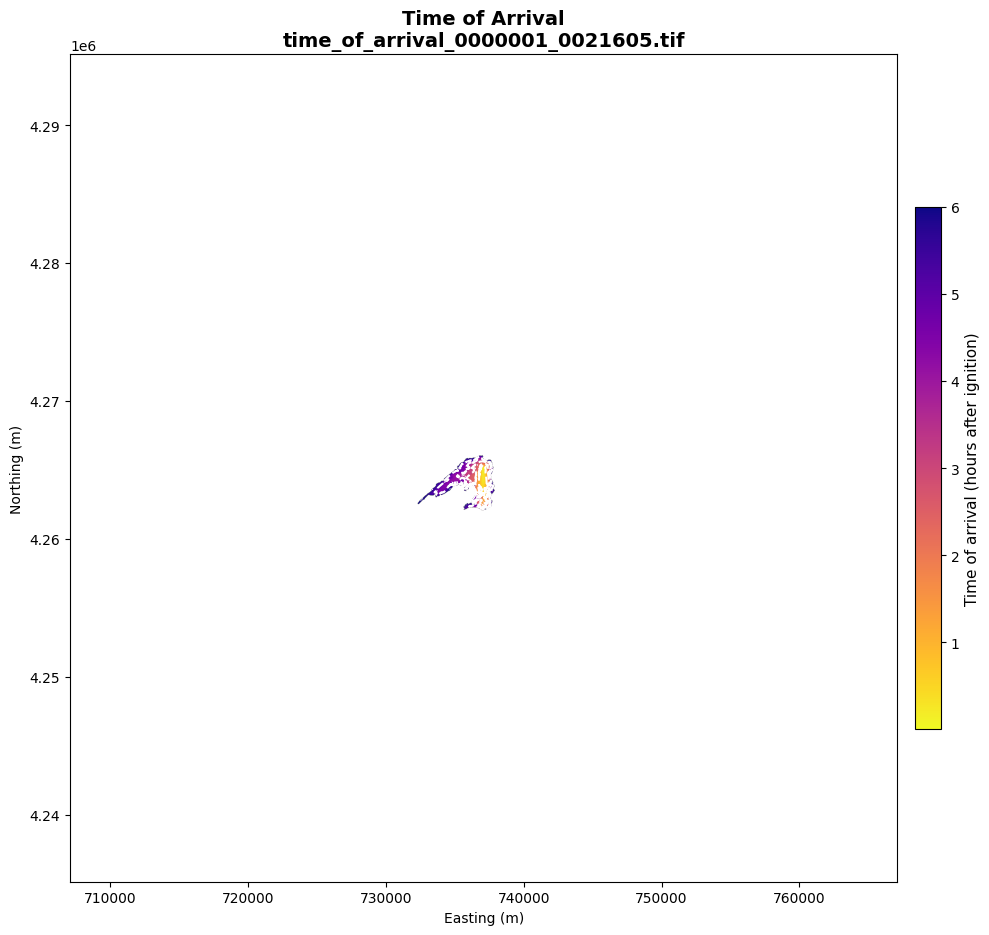

Saved: time_of_arrival_0000001_0021605_viz.png


In [16]:
toa_files = sorted(glob.glob(str(OUTPUTS / "time_of_arrival_*.tif")))
print(f"Found {len(toa_files)} time-of-arrival raster(s):")
for f in toa_files:
    print(f"  {os.path.basename(f)}")

for toa_path in toa_files:
    with rasterio.open(toa_path) as src:
        data = src.read(1).astype(float)
        nodata = src.nodata
        transform = src.transform
        crs = src.crs
        bounds = src.bounds

    # Mask nodata and unburned (value -9999 or very large)
    data = np.where((data == nodata) | (data < 0) | (data > 1e7), np.nan, data)
    data_hours = data / 3600.0  # convert seconds → hours

    fig, ax = plt.subplots(figsize=(10, 10))

    cmap = plt.cm.plasma_r
    vmin, vmax = np.nanmin(data_hours), np.nanmax(data_hours)
    im = ax.imshow(
        data_hours,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    )

    # Overlay fire perimeters (reproject to match raster CRS)
    iso_native = iso.to_crs(crs)
    iso_native.plot(ax=ax, edgecolor="white", facecolor="none", linewidth=1.5, linestyle="--")

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Time of arrival (hours after ignition)", fontsize=11)

    ax.set_title(f"Time of Arrival\n{os.path.basename(toa_path)}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    plt.tight_layout()
    out_png = OUTPUTS / (Path(toa_path).stem + "_viz.png")
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_png.name}")

## 4. Fireline Intensity Raster (kW/m)
Fireline intensity (Byram's intensity) — higher = more intense fire, harder to suppress.

| Intensity (kW/m) | Behavior |
|---|---|
| < 500 | Ground crew can engage |
| 500–3,000 | Difficult — aerial resources needed |
| > 3,000 | Extreme — no suppression possible |

Found 1 fireline intensity raster(s):
  flin_0000001_0021605.tif


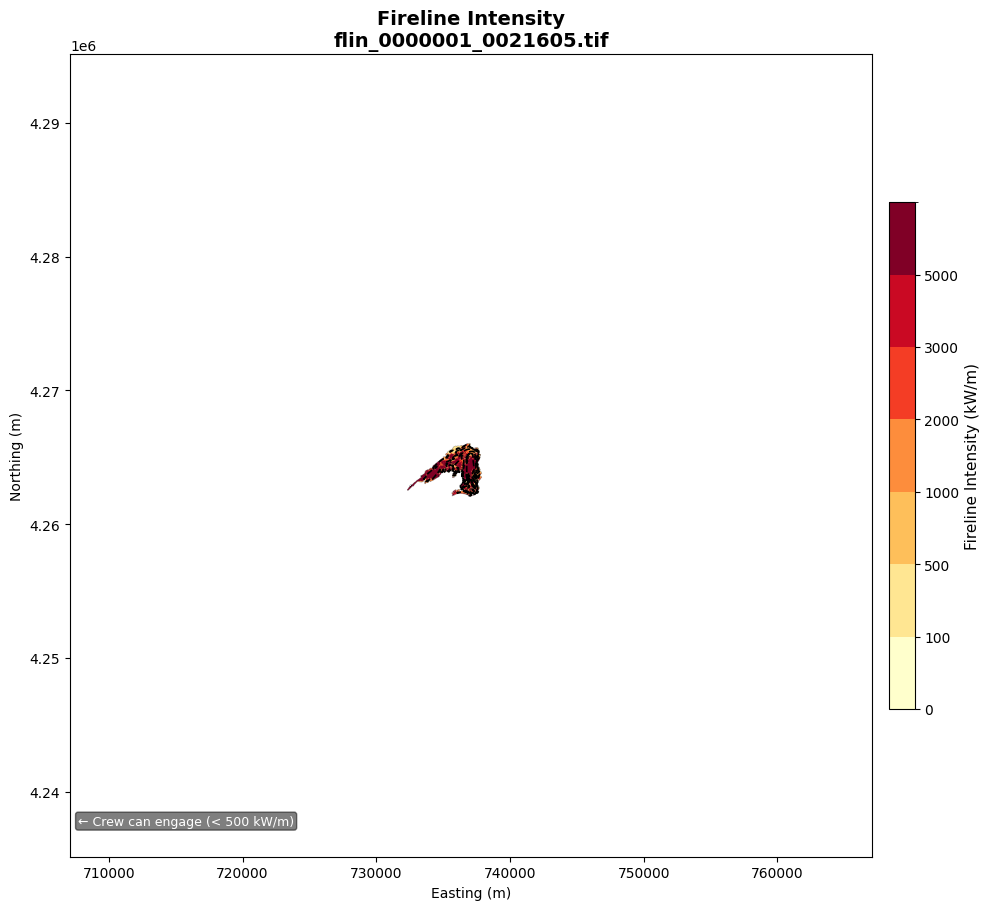

Peak intensity: 127,842 kW/m
Mean intensity (burned cells): 20,830 kW/m
Saved: flin_0000001_0021605_viz.png


In [17]:
flin_files = sorted(glob.glob(str(OUTPUTS / "flin_*.tif")))
print(f"Found {len(flin_files)} fireline intensity raster(s):")
for f in flin_files:
    print(f"  {os.path.basename(f)}")

for flin_path in flin_files:
    with rasterio.open(flin_path) as src:
        data = src.read(1).astype(float)
        nodata = src.nodata
        transform = src.transform
        crs = src.crs
        bounds = src.bounds

    data = np.where((data == nodata) | (data < 0), np.nan, data)

    # Log scale helps compress the wide dynamic range of fire intensity
    data_log = np.log10(data + 1)

    # Intensity classification boundaries (kW/m)
    levels = [0, 100, 500, 1000, 2000, 3000, 5000, np.nanmax(data) + 1]
    cmap_flin = plt.cm.get_cmap("YlOrRd", len(levels) - 1)

    fig, ax = plt.subplots(figsize=(10, 10))
    im = ax.imshow(
        data,
        cmap=cmap_flin,
        norm=mcolors.BoundaryNorm(levels, cmap_flin.N),
        extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    )

    iso_native = iso.to_crs(crs)
    iso_native.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=1.2, linestyle="--")

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Fireline Intensity (kW/m)", fontsize=11)
    cbar.set_ticks(levels[:-1])
    cbar.set_ticklabels([f"{int(l)}" for l in levels[:-1]])

    # Annotate suppression thresholds
    ax.annotate("← Crew can engage (< 500 kW/m)",
                xy=(0.01, 0.04), xycoords="axes fraction",
                fontsize=9, color="white",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.5))

    ax.set_title(f"Fireline Intensity\n{os.path.basename(flin_path)}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    plt.tight_layout()
    out_png = OUTPUTS / (Path(flin_path).stem + "_viz.png")
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Peak intensity: {np.nanmax(data):,.0f} kW/m")
    print(f"Mean intensity (burned cells): {np.nanmean(data[data > 0]):,.0f} kW/m")
    print(f"Saved: {out_png.name}")

## 5. Fire Size Statistics (CSV)
Fire area (acres) over simulation time, plus derived rate of spread.

In [18]:
csv_path = OUTPUTS / "fire_size_stats.csv"
df = pd.read_csv(csv_path)
print(df.head(10))
print(f"\nColumns: {df.columns.tolist()}")

   icase  Meteorology band    x    y  tstop (h)  Wall clock time (s)  \
0      1                 1  0.0  0.0        6.0                2.316   

   Total fire area (ac)  Crown fire area (ac)  Fire volume (ac-ft)  \
0                2263.8                1426.7              42415.6   

   Population affected  Real estate value  Land value  Nembers  Pyrome  \
0                 -1.0               -1.0        -1.0        0       1   

   Containfrac  PM 2.5 release (ug)  HRR peak (MW)   Start timestamp  Fire id  \
0      -9999.0                  0.0            0.0  1970-01-01 00:00        1   

     Astop (ac)  
0  9.000000e+09  

Columns: ['icase', 'Meteorology band', 'x', 'y', 'tstop (h)', 'Wall clock time (s)', 'Total fire area (ac)', 'Crown fire area (ac)', 'Fire volume (ac-ft)', 'Population affected', 'Real estate value', 'Land value', 'Nembers', 'Pyrome', 'Containfrac', 'PM 2.5 release (ug)', 'HRR peak (MW)', 'Start timestamp', 'Fire id', 'Astop (ac)']


── Simulation Summary ──────────────────────────────
  Duration            : 6.0 hours
  Total fire area     : 2,264 acres  (3.5 sq miles)
  Crown fire area     : 1,427 acres  (63% of total)
  Surface fire area   : 837 acres
  Fire volume         : 42,416 ac-ft
  Approx. avg spread  : 0.18 mph (equivalent circular spread)
────────────────────────────────────────────────────


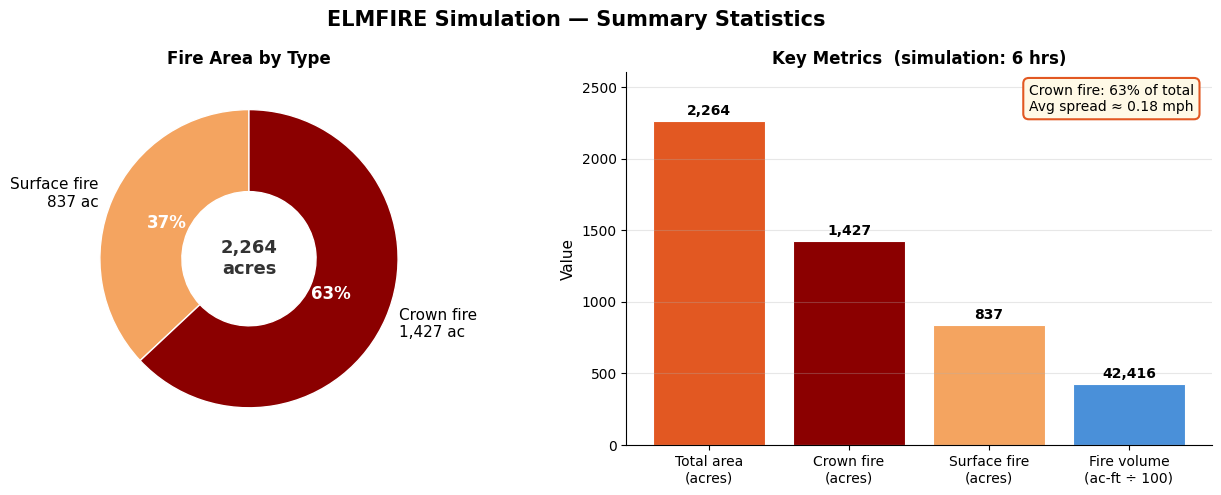

Saved: viz_fire_size_stats.png


In [19]:
df.columns = [c.strip() for c in df.columns]   # strip any whitespace

# ── Key metrics ──────────────────────────────────────────────────────────────
total_area   = df["Total fire area (ac)"].iloc[0]
crown_area   = df["Crown fire area (ac)"].iloc[0]
fire_vol     = df["Fire volume (ac-ft)"].iloc[0]
sim_hours    = df["tstop (h)"].iloc[0]
surface_area = total_area - crown_area
crown_pct    = 100 * crown_area / total_area if total_area > 0 else 0

# Derive: average spread rate (radius ≈ √(area/π), rate = radius / hours)
import math
radius_mi      = math.sqrt(total_area / math.pi / 640)     # acres → sq miles → radius
avg_ros_mph    = radius_mi / sim_hours if sim_hours > 0 else 0

print(f"── Simulation Summary ──────────────────────────────")
print(f"  Duration            : {sim_hours:.1f} hours")
print(f"  Total fire area     : {total_area:,.0f} acres  ({total_area/640:.1f} sq miles)")
print(f"  Crown fire area     : {crown_area:,.0f} acres  ({crown_pct:.0f}% of total)")
print(f"  Surface fire area   : {surface_area:,.0f} acres")
print(f"  Fire volume         : {fire_vol:,.0f} ac-ft")
print(f"  Approx. avg spread  : {avg_ros_mph:.2f} mph (equivalent circular spread)")
print(f"────────────────────────────────────────────────────")

# ── Visual metrics dashboard ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("ELMFIRE Simulation — Summary Statistics", fontsize=15, fontweight="bold")

# Left: Fire area breakdown (donut chart)
ax = axes[0]
sizes  = [surface_area, crown_area]
labels = [f"Surface fire\n{surface_area:,.0f} ac", f"Crown fire\n{crown_area:,.0f} ac"]
colors = ["#f4a460", "#8b0000"]
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors,
    autopct="%1.0f%%", startangle=90,
    wedgeprops=dict(width=0.55, edgecolor="white"),
    textprops=dict(fontsize=11),
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight("bold")
    at.set_color("white")
circle = plt.Circle((0, 0), 0.35, color="white")
ax.add_patch(circle)
ax.text(0, 0, f"{total_area:,.0f}\nacres", ha="center", va="center",
        fontsize=13, fontweight="bold", color="#333")
ax.set_title("Fire Area by Type", fontsize=12, fontweight="bold")

# Right: Key metrics bar chart
ax2 = axes[1]
metric_names  = ["Total area\n(acres)", "Crown fire\n(acres)", "Surface fire\n(acres)", "Fire volume\n(ac-ft ÷ 100)"]
metric_values = [total_area, crown_area, surface_area, fire_vol / 100]
bar_colors    = ["#e25822", "#8b0000", "#f4a460", "#4a90d9"]
bars = ax2.bar(metric_names, metric_values, color=bar_colors, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, [total_area, crown_area, surface_area, fire_vol]):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
             f"{val:,.0f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.set_ylabel("Value", fontsize=11)
ax2.set_title(f"Key Metrics  (simulation: {sim_hours:.0f} hrs)", fontsize=12, fontweight="bold")
ax2.grid(axis="y", alpha=0.3)
ax2.set_ylim(0, max(metric_values) * 1.15)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# Annotation box
bbox_props = dict(boxstyle="round,pad=0.4", facecolor="#fff9e6", edgecolor="#e25822", linewidth=1.5)
ax2.text(0.97, 0.97,
         f"Crown fire: {crown_pct:.0f}% of total\nAvg spread ≈ {avg_ros_mph:.2f} mph",
         transform=ax2.transAxes, ha="right", va="top", fontsize=10, bbox=bbox_props)

plt.tight_layout()
plt.savefig(OUTPUTS / "viz_fire_size_stats.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: viz_fire_size_stats.png")

# Expose variables for combined panel
t = pd.Series([0, sim_hours])
a = pd.Series([0, total_area])
da_dt = np.array([total_area / sim_hours, total_area / sim_hours])
time_label = "Time (hours)"

## 6. Combined Multi-Panel Summary Map
All four outputs in a single 2×2 figure — the best single image to share.

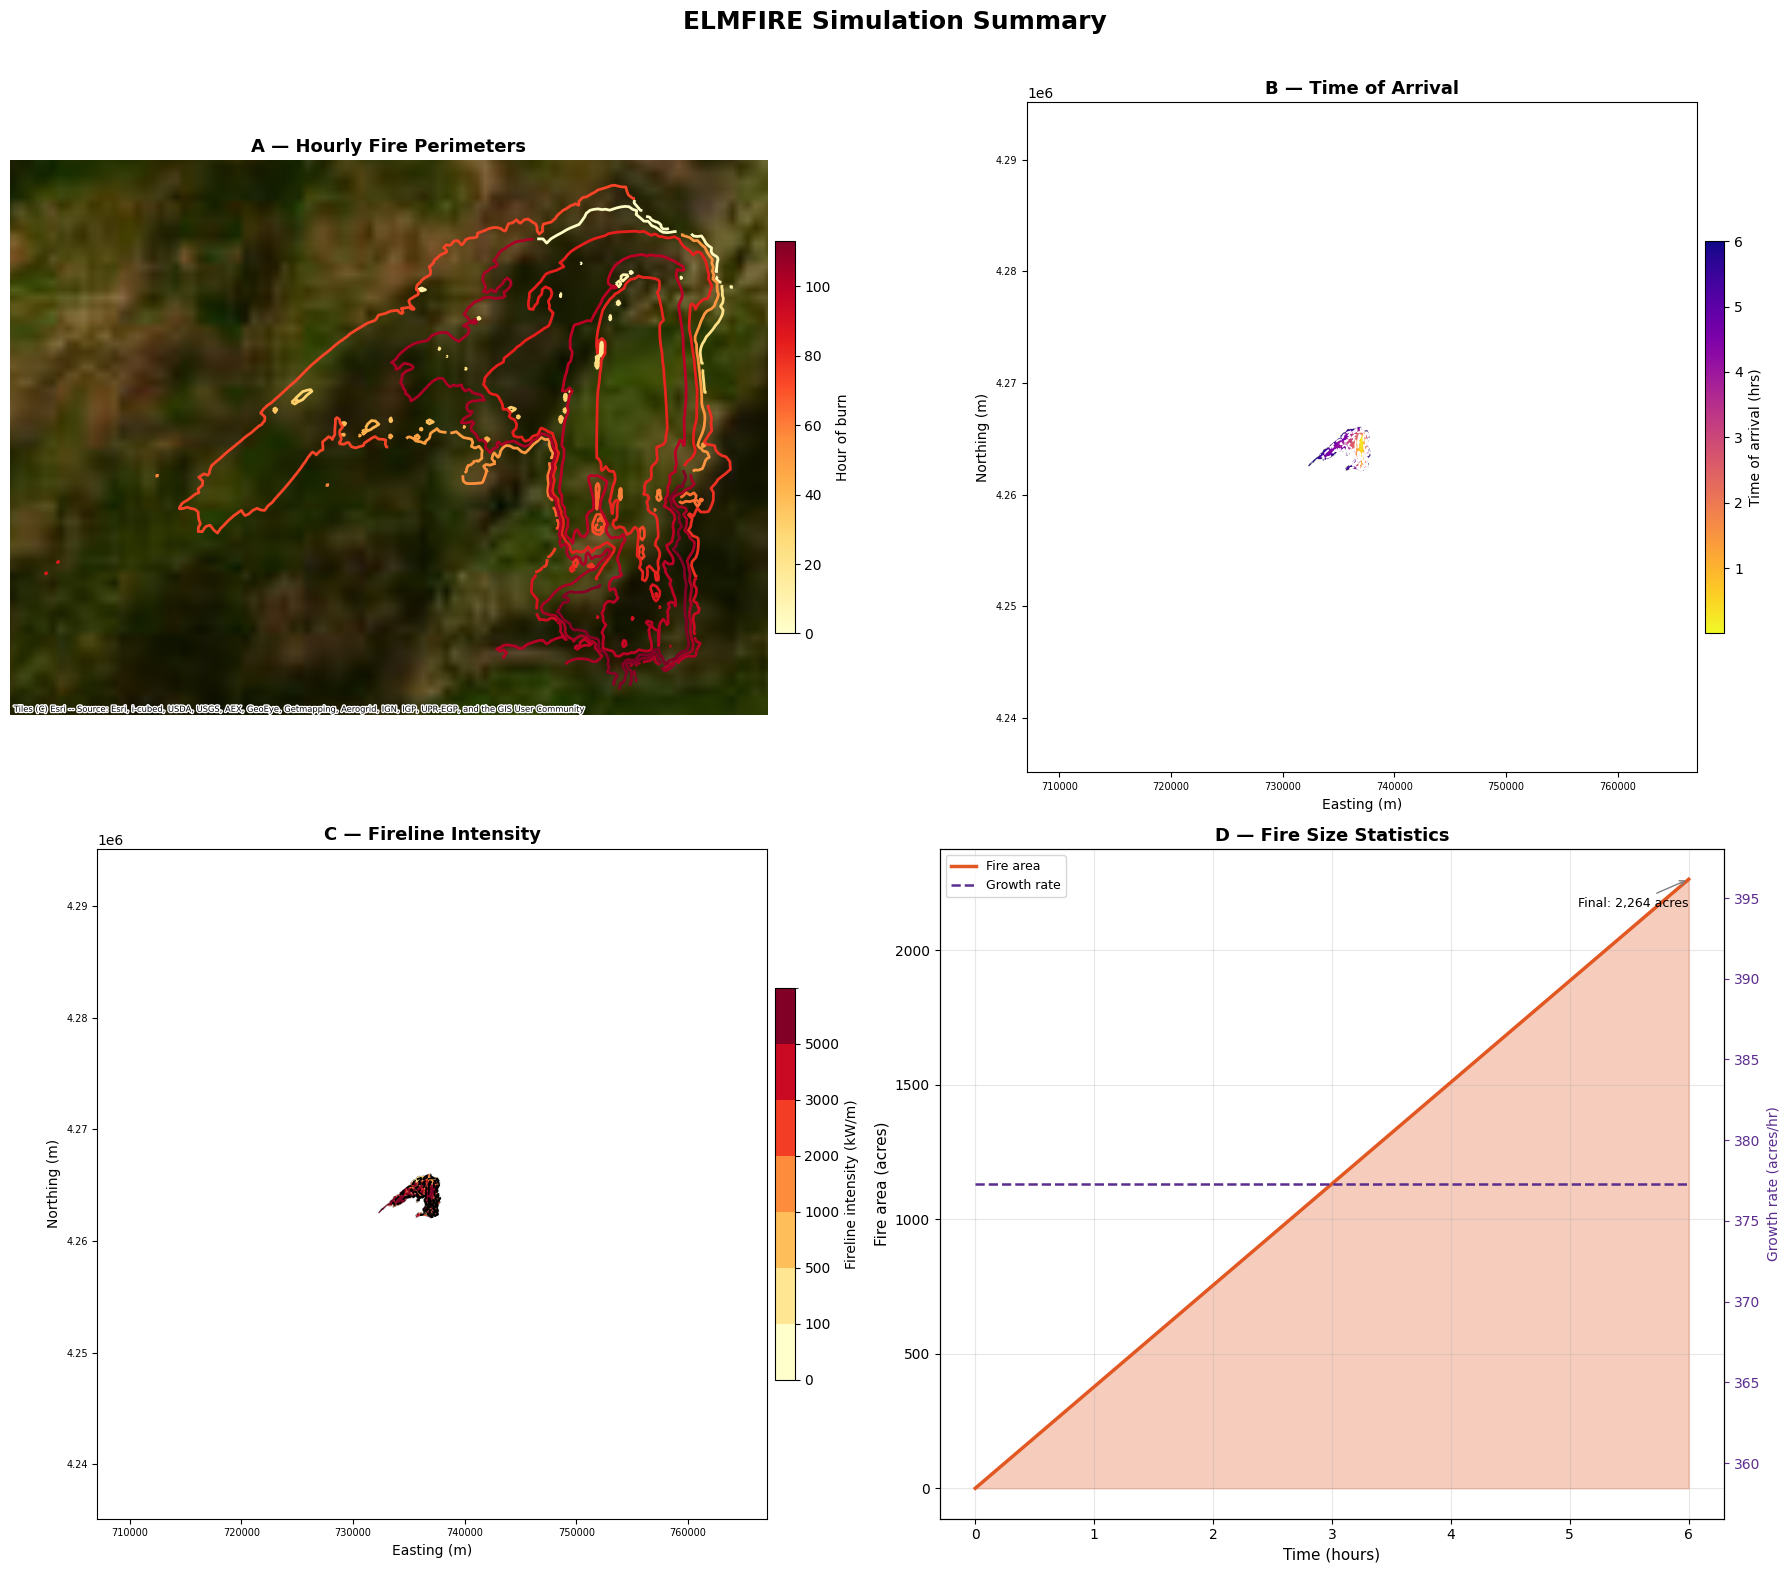

Saved: docker_shared_folder\simulation\outputs\viz_combined_summary.png


In [20]:
toa_path  = toa_files[0]
flin_path = flin_files[0]

with rasterio.open(toa_path) as src:
    toa_data  = src.read(1).astype(float)
    toa_nd    = src.nodata
    crs       = src.crs
    bounds    = src.bounds
    extent    = [bounds.left, bounds.right, bounds.bottom, bounds.top]

with rasterio.open(flin_path) as src:
    flin_data = src.read(1).astype(float)
    flin_nd   = src.nodata

toa_data  = np.where((toa_data  == toa_nd)  | (toa_data  < 0), np.nan, toa_data  / 3600)
flin_data = np.where((flin_data == flin_nd) | (flin_data < 0), np.nan, flin_data)

iso_native = iso.to_crs(crs)

fig, axes = plt.subplots(2, 2, figsize=(18, 16))
fig.suptitle("ELMFIRE Simulation Summary", fontsize=18, fontweight="bold", y=0.98)

# ── Panel A: Isochrones on satellite ──────────────────────────────────────────
ax = axes[0, 0]
iso_wm2 = iso.to_crs(epsg=3857)
iso_wm2["hour_col"] = iso_wm2[color_col] if "hour_col" not in iso_wm2.columns else iso_wm2["hour_col"]
iso_wm2.plot(column=color_col, ax=ax, cmap="YlOrRd",
             norm=Normalize(iso_wm2[color_col].min(), iso_wm2[color_col].max()),
             linewidth=2, legend=False)
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, zoom=11, attribution_size=6)
ax.set_axis_off()
ax.set_title("A — Hourly Fire Perimeters", fontsize=13, fontweight="bold")
sm = cm.ScalarMappable(cmap="YlOrRd", norm=Normalize(iso_wm2[color_col].min(), iso_wm2[color_col].max()))
sm.set_array([])
fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.01, label="Hour of burn")

# ── Panel B: Time of Arrival ───────────────────────────────────────────────────
ax = axes[0, 1]
im = ax.imshow(toa_data, cmap="plasma_r",
               vmin=np.nanmin(toa_data), vmax=np.nanmax(toa_data), extent=extent)
iso_native.plot(ax=ax, edgecolor="white", facecolor="none", linewidth=1.2, linestyle="--")
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01, label="Time of arrival (hrs)")
ax.set_title("B — Time of Arrival", fontsize=13, fontweight="bold")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
ax.tick_params(labelsize=7)

# ── Panel C: Fireline Intensity ───────────────────────────────────────────────
ax = axes[1, 0]
levels = [0, 100, 500, 1000, 2000, 3000, 5000, max(np.nanmax(flin_data) + 1, 5001)]
cmap_flin = plt.cm.get_cmap("YlOrRd", len(levels) - 1)
im2 = ax.imshow(flin_data, cmap=cmap_flin,
                norm=mcolors.BoundaryNorm(levels, cmap_flin.N), extent=extent)
iso_native.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=1.2, linestyle="--")
cb = fig.colorbar(im2, ax=ax, fraction=0.025, pad=0.01, label="Fireline intensity (kW/m)")
cb.set_ticks(levels[:-1]); cb.set_ticklabels([str(int(l)) for l in levels[:-1]])
ax.set_title("C — Fireline Intensity", fontsize=13, fontweight="bold")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
ax.tick_params(labelsize=7)

# ── Panel D: Fire size growth ─────────────────────────────────────────────────
ax = axes[1, 1]
ax.fill_between(t, a, alpha=0.3, color="#e25822")
ax.plot(t, a, color="#e25822", linewidth=2.5, label="Fire area")
ax2d = ax.twinx()
ax2d.plot(t, da_dt.clip(min=0), color="#5b2d8e", linewidth=1.8, linestyle="--", label="Growth rate")
ax2d.set_ylabel("Growth rate (acres/hr)", fontsize=10, color="#5b2d8e")
ax2d.tick_params(colors="#5b2d8e")
ax.set_xlabel(time_label, fontsize=11)
ax.set_ylabel("Fire area (acres)", fontsize=11)
ax.set_title("D — Fire Size Statistics", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)
lines1, lbl1 = ax.get_legend_handles_labels()
lines2, lbl2 = ax2d.get_legend_handles_labels()
ax.legend(lines1 + lines2, lbl1 + lbl2, fontsize=9, loc="upper left")
ax.annotate(f"Final: {a.iloc[-1]:,.0f} acres",
            xy=(t.iloc[-1], a.iloc[-1]),
            xytext=(-80, -20), textcoords="offset points", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="gray"))

plt.tight_layout(rect=[0, 0, 1, 0.97])
out_combined = OUTPUTS / "viz_combined_summary.png"
plt.savefig(out_combined, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_combined}")

## 7. Interactive Web Map (Folium)
Zoomable/pannable map with fire perimeters layered over satellite imagery. Opens inline in the notebook.

In [21]:
import folium
import json

# Reproject to WGS84 for Folium
iso_wgs = iso.to_crs(epsg=4326)
center  = [iso_wgs.geometry.centroid.y.mean(), iso_wgs.geometry.centroid.x.mean()]

m = folium.Map(location=center, zoom_start=11,
               tiles="Esri.WorldImagery",
               attr="Esri World Imagery")

# Color each perimeter by hour
vals_wgs = iso_wgs[color_col].values
norm_v   = (vals_wgs - vals_wgs.min()) / (vals_wgs.max() - vals_wgs.min() + 1e-9)
colormap = plt.cm.YlOrRd

for idx, row in iso_wgs.iterrows():
    v   = row[color_col]
    nv  = (v - vals_wgs.min()) / (vals_wgs.max() - vals_wgs.min() + 1e-9)
    rgb = colormap(nv)
    hex_color = "#{:02x}{:02x}{:02x}".format(int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255))

    geojson = row.geometry.__geo_interface__
    tooltip_val = f"Hour: {v/3600:.1f} hr" if v > 1000 else f"{color_col}: {v}"
    folium.GeoJson(
        geojson,
        style_function=lambda _, c=hex_color: {
            "color": c, "weight": 2.5, "fillOpacity": 0.0
        },
        tooltip=tooltip_val,
    ).add_to(m)

# Add ignition point marker at centroid of innermost perimeter
innermost = iso_wgs.iloc[[0]]
ign_lat   = innermost.geometry.centroid.y.values[0]
ign_lon   = innermost.geometry.centroid.x.values[0]
folium.Marker(
    location=[ign_lat, ign_lon],
    tooltip="Ignition point",
    icon=folium.Icon(color="red", icon="fire", prefix="fa"),
).add_to(m)

out_html = OUTPUTS / "viz_interactive_map.html"
m.save(str(out_html))
print(f"Saved: {out_html}")
print("Open viz_interactive_map.html in your browser for a pannable/zoomable map.")
m  # display inline in notebook

Saved: docker_shared_folder\simulation\outputs\viz_interactive_map.html
Open viz_interactive_map.html in your browser for a pannable/zoomable map.
